In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings 
warnings.filterwarnings('ignore')
df = pd.read_csv("../data/application_train_features.csv")

X = df.drop(columns="TARGET")
y = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numerical_features = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape:", X_train_processed.shape)
print("Processed Testing Shape :", X_test_processed.shape)

Processed Training Shape: (246008, 254)
Processed Testing Shape : (61503, 254)


In [28]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'class_weight': 'balanced',
        'random_state': 42,
        'verbose': -1
    }
    
    model = LGBMClassifier(**params)
    model.fit(X_train_processed, y_train)
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    return roc_auc_score(y_test, y_prob)



In [27]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, ConfusionMatrixDisplay)

In [20]:
study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=30,
    show_progress_bar=True
)

[I 2026-07-23 16:11:09,261] A new study created in memory with name: no-name-aaabcd63-43dc-407d-90f3-3359b17957ac
Best trial: 0. Best value: 0.760558:   3%|██████                                                                                                                                                                               | 1/30 [00:04<02:23,  4.95s/it]

[I 2026-07-23 16:11:14,238] Trial 0 finished with value: 0.7605578538253395 and parameters: {'n_estimators': 213, 'learning_rate': 0.06883133026074024, 'num_leaves': 48, 'max_depth': 12, 'min_child_samples': 7, 'subsample': 0.619183479481728, 'colsample_bytree': 0.8064507126659665}. Best is trial 0 with value: 0.7605578538253395.


Best trial: 1. Best value: 0.761302:   7%|████████████                                                                                                                                                                         | 2/30 [00:09<02:07,  4.54s/it]

[I 2026-07-23 16:11:18,493] Trial 1 finished with value: 0.7613019638655633 and parameters: {'n_estimators': 411, 'learning_rate': 0.1046710067841649, 'num_leaves': 99, 'max_depth': 4, 'min_child_samples': 58, 'subsample': 0.6801706297007939, 'colsample_bytree': 0.8536205707460711}. Best is trial 1 with value: 0.7613019638655633.


Best trial: 1. Best value: 0.761302:  10%|██████████████████                                                                                                                                                                   | 3/30 [00:17<02:43,  6.05s/it]

[I 2026-07-23 16:11:26,342] Trial 2 finished with value: 0.7554001075197685 and parameters: {'n_estimators': 206, 'learning_rate': 0.01539093568915309, 'num_leaves': 120, 'max_depth': 12, 'min_child_samples': 74, 'subsample': 0.7061811540065676, 'colsample_bytree': 0.9714098856696503}. Best is trial 1 with value: 0.7613019638655633.


Best trial: 1. Best value: 0.761302:  13%|████████████████████████▏                                                                                                                                                            | 4/30 [00:22<02:33,  5.90s/it]

[I 2026-07-23 16:11:32,016] Trial 3 finished with value: 0.7337895887790999 and parameters: {'n_estimators': 334, 'learning_rate': 0.18821180277148758, 'num_leaves': 135, 'max_depth': 7, 'min_child_samples': 6, 'subsample': 0.7998045144749598, 'colsample_bytree': 0.6902135458176564}. Best is trial 1 with value: 0.7613019638655633.


Best trial: 1. Best value: 0.761302:  17%|██████████████████████████████▏                                                                                                                                                      | 5/30 [00:25<02:00,  4.83s/it]

[I 2026-07-23 16:11:34,932] Trial 4 finished with value: 0.7362609884743809 and parameters: {'n_estimators': 176, 'learning_rate': 0.01573366993972873, 'num_leaves': 27, 'max_depth': 3, 'min_child_samples': 25, 'subsample': 0.6909412072317516, 'colsample_bytree': 0.6595655438461328}. Best is trial 1 with value: 0.7613019638655633.


Best trial: 1. Best value: 0.761302:  20%|████████████████████████████████████▏                                                                                                                                                | 6/30 [00:29<01:49,  4.58s/it]

[I 2026-07-23 16:11:39,023] Trial 5 finished with value: 0.7543808605834957 and parameters: {'n_estimators': 139, 'learning_rate': 0.1390540249245375, 'num_leaves': 109, 'max_depth': 9, 'min_child_samples': 91, 'subsample': 0.706209194108534, 'colsample_bytree': 0.8708268332632858}. Best is trial 1 with value: 0.7613019638655633.


Best trial: 1. Best value: 0.761302:  23%|██████████████████████████████████████████▏                                                                                                                                          | 7/30 [00:32<01:33,  4.05s/it]

[I 2026-07-23 16:11:42,005] Trial 6 finished with value: 0.7593785776319482 and parameters: {'n_estimators': 105, 'learning_rate': 0.10207424318844203, 'num_leaves': 43, 'max_depth': 6, 'min_child_samples': 67, 'subsample': 0.9686699186357735, 'colsample_bytree': 0.7207186437853402}. Best is trial 1 with value: 0.7613019638655633.


Best trial: 1. Best value: 0.761302:  27%|████████████████████████████████████████████████▎                                                                                                                                    | 8/30 [00:36<01:29,  4.07s/it]

[I 2026-07-23 16:11:46,107] Trial 7 finished with value: 0.7605993769325247 and parameters: {'n_estimators': 164, 'learning_rate': 0.0657838488215579, 'num_leaves': 52, 'max_depth': 12, 'min_child_samples': 15, 'subsample': 0.7735386735210212, 'colsample_bytree': 0.7785980507596971}. Best is trial 1 with value: 0.7613019638655633.


Best trial: 1. Best value: 0.761302:  30%|██████████████████████████████████████████████████████▎                                                                                                                              | 9/30 [00:45<01:57,  5.61s/it]

[I 2026-07-23 16:11:55,091] Trial 8 finished with value: 0.7599568588595886 and parameters: {'n_estimators': 425, 'learning_rate': 0.014721080282167459, 'num_leaves': 44, 'max_depth': 12, 'min_child_samples': 17, 'subsample': 0.996041925147763, 'colsample_bytree': 0.9649323510148577}. Best is trial 1 with value: 0.7613019638655633.


Best trial: 1. Best value: 0.761302:  33%|████████████████████████████████████████████████████████████                                                                                                                        | 10/30 [00:48<01:33,  4.67s/it]

[I 2026-07-23 16:11:57,672] Trial 9 finished with value: 0.7377632977697325 and parameters: {'n_estimators': 141, 'learning_rate': 0.02150131636226993, 'num_leaves': 57, 'max_depth': 3, 'min_child_samples': 63, 'subsample': 0.8262196782247534, 'colsample_bytree': 0.8191667131683475}. Best is trial 1 with value: 0.7613019638655633.


Best trial: 1. Best value: 0.761302:  37%|██████████████████████████████████████████████████████████████████                                                                                                                  | 11/30 [00:53<01:33,  4.92s/it]

[I 2026-07-23 16:12:03,144] Trial 10 finished with value: 0.7382162704818621 and parameters: {'n_estimators': 492, 'learning_rate': 0.27771475818982794, 'num_leaves': 90, 'max_depth': 5, 'min_child_samples': 41, 'subsample': 0.8924551835565213, 'colsample_bytree': 0.9064853112963926}. Best is trial 1 with value: 0.7613019638655633.


Best trial: 1. Best value: 0.761302:  40%|████████████████████████████████████████████████████████████████████████                                                                                                            | 12/30 [01:00<01:37,  5.42s/it]

[I 2026-07-23 16:12:09,699] Trial 11 finished with value: 0.7612747935894393 and parameters: {'n_estimators': 288, 'learning_rate': 0.04180674018554778, 'num_leaves': 83, 'max_depth': 9, 'min_child_samples': 38, 'subsample': 0.7794574139499304, 'colsample_bytree': 0.7757211863588831}. Best is trial 1 with value: 0.7613019638655633.


Best trial: 12. Best value: 0.76163:  43%|██████████████████████████████████████████████████████████████████████████████                                                                                                      | 13/30 [01:07<01:41,  5.95s/it]

[I 2026-07-23 16:12:16,882] Trial 12 finished with value: 0.7616296244998018 and parameters: {'n_estimators': 313, 'learning_rate': 0.0330311651059116, 'num_leaves': 84, 'max_depth': 9, 'min_child_samples': 44, 'subsample': 0.602979904430956, 'colsample_bytree': 0.7557447840143754}. Best is trial 12 with value: 0.7616296244998018.


Best trial: 13. Best value: 0.761703:  47%|███████████████████████████████████████████████████████████████████████████████████▌                                                                                               | 14/30 [01:15<01:45,  6.62s/it]

[I 2026-07-23 16:12:25,049] Trial 13 finished with value: 0.7617033087782007 and parameters: {'n_estimators': 385, 'learning_rate': 0.032050995834205044, 'num_leaves': 78, 'max_depth': 8, 'min_child_samples': 50, 'subsample': 0.6005755029949728, 'colsample_bytree': 0.6207326596653582}. Best is trial 13 with value: 0.7617033087782007.


Best trial: 13. Best value: 0.761703:  50%|█████████████████████████████████████████████████████████████████████████████████████████▌                                                                                         | 15/30 [01:23<01:42,  6.83s/it]

[I 2026-07-23 16:12:32,355] Trial 14 finished with value: 0.7612162601153348 and parameters: {'n_estimators': 310, 'learning_rate': 0.027339900266353936, 'num_leaves': 70, 'max_depth': 9, 'min_child_samples': 42, 'subsample': 0.6021643350201739, 'colsample_bytree': 0.609966707652631}. Best is trial 13 with value: 0.7617033087782007.


Best trial: 13. Best value: 0.761703:  53%|███████████████████████████████████████████████████████████████████████████████████████████████▍                                                                                   | 16/30 [01:30<01:39,  7.14s/it]

[I 2026-07-23 16:12:40,210] Trial 15 finished with value: 0.7611834185294444 and parameters: {'n_estimators': 368, 'learning_rate': 0.03806917349535898, 'num_leaves': 76, 'max_depth': 8, 'min_child_samples': 54, 'subsample': 0.6428427060199124, 'colsample_bytree': 0.6071584680625264}. Best is trial 13 with value: 0.7617033087782007.


Best trial: 13. Best value: 0.761703:  57%|█████████████████████████████████████████████████████████████████████████████████████████████████████▍                                                                             | 17/30 [01:38<01:33,  7.22s/it]

[I 2026-07-23 16:12:47,613] Trial 16 finished with value: 0.7600270341931887 and parameters: {'n_estimators': 262, 'learning_rate': 0.03849317198193535, 'num_leaves': 146, 'max_depth': 10, 'min_child_samples': 84, 'subsample': 0.6528445737683171, 'colsample_bytree': 0.7300169827693826}. Best is trial 13 with value: 0.7617033087782007.


Best trial: 13. Best value: 0.761703:  60%|███████████████████████████████████████████████████████████████████████████████████████████████████████████▍                                                                       | 18/30 [01:46<01:31,  7.60s/it]

[I 2026-07-23 16:12:56,098] Trial 17 finished with value: 0.7549121255132099 and parameters: {'n_estimators': 400, 'learning_rate': 0.010099711486871419, 'num_leaves': 64, 'max_depth': 7, 'min_child_samples': 51, 'subsample': 0.6078042090935497, 'colsample_bytree': 0.6637767674147651}. Best is trial 13 with value: 0.7617033087782007.


Best trial: 13. Best value: 0.761703:  63%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                 | 19/30 [01:54<01:23,  7.63s/it]

[I 2026-07-23 16:13:03,793] Trial 18 finished with value: 0.7591533995601243 and parameters: {'n_estimators': 484, 'learning_rate': 0.05183203128880378, 'num_leaves': 100, 'max_depth': 7, 'min_child_samples': 31, 'subsample': 0.7302817913409454, 'colsample_bytree': 0.7351497859441141}. Best is trial 13 with value: 0.7617033087782007.


Best trial: 13. Best value: 0.761703:  67%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                           | 20/30 [02:03<01:20,  8.09s/it]

[I 2026-07-23 16:13:12,978] Trial 19 finished with value: 0.7614580032565145 and parameters: {'n_estimators': 358, 'learning_rate': 0.02607178313011306, 'num_leaves': 121, 'max_depth': 10, 'min_child_samples': 100, 'subsample': 0.6545571320436003, 'colsample_bytree': 0.6448231804859623}. Best is trial 13 with value: 0.7617033087782007.


Best trial: 13. Best value: 0.761703:  70%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                     | 21/30 [02:10<01:09,  7.69s/it]

[I 2026-07-23 16:13:19,733] Trial 20 finished with value: 0.7605786759394004 and parameters: {'n_estimators': 262, 'learning_rate': 0.027334476168180077, 'num_leaves': 80, 'max_depth': 10, 'min_child_samples': 48, 'subsample': 0.6437131949698085, 'colsample_bytree': 0.6983934039704045}. Best is trial 13 with value: 0.7617033087782007.


Best trial: 21. Best value: 0.762199:  73%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                               | 22/30 [02:19<01:05,  8.19s/it]

[I 2026-07-23 16:13:29,098] Trial 21 finished with value: 0.7621987646590622 and parameters: {'n_estimators': 349, 'learning_rate': 0.026893915216046605, 'num_leaves': 121, 'max_depth': 10, 'min_child_samples': 78, 'subsample': 0.6576670035497199, 'colsample_bytree': 0.6353716160445806}. Best is trial 21 with value: 0.7621987646590622.


Best trial: 21. Best value: 0.762199:  77%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                         | 23/30 [02:29<00:59,  8.52s/it]

[I 2026-07-23 16:13:38,369] Trial 22 finished with value: 0.7604500276921649 and parameters: {'n_estimators': 360, 'learning_rate': 0.01929986818136354, 'num_leaves': 120, 'max_depth': 8, 'min_child_samples': 80, 'subsample': 0.7323859474420497, 'colsample_bytree': 0.6287812362523436}. Best is trial 21 with value: 0.7621987646590622.


Best trial: 21. Best value: 0.762199:  80%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                   | 24/30 [02:38<00:53,  8.85s/it]

[I 2026-07-23 16:13:47,993] Trial 23 finished with value: 0.7616758178878311 and parameters: {'n_estimators': 448, 'learning_rate': 0.030976174648277077, 'num_leaves': 92, 'max_depth': 10, 'min_child_samples': 71, 'subsample': 0.6002423241932122, 'colsample_bytree': 0.6626624576879518}. Best is trial 21 with value: 0.7621987646590622.


Best trial: 21. Best value: 0.762199:  83%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                             | 25/30 [02:47<00:44,  8.86s/it]

[I 2026-07-23 16:13:56,887] Trial 24 finished with value: 0.7582766157826922 and parameters: {'n_estimators': 449, 'learning_rate': 0.05315270708218091, 'num_leaves': 98, 'max_depth': 11, 'min_child_samples': 71, 'subsample': 0.6699627028914167, 'colsample_bytree': 0.6875541625692873}. Best is trial 21 with value: 0.7621987646590622.


Best trial: 21. Best value: 0.762199:  87%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                       | 26/30 [03:00<00:40, 10.19s/it]

[I 2026-07-23 16:14:10,177] Trial 25 finished with value: 0.7592638761043957 and parameters: {'n_estimators': 447, 'learning_rate': 0.010408485824773661, 'num_leaves': 132, 'max_depth': 11, 'min_child_samples': 80, 'subsample': 0.6330896780636174, 'colsample_bytree': 0.6374515472861334}. Best is trial 21 with value: 0.7621987646590622.


Best trial: 21. Best value: 0.762199:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                  | 27/30 [03:10<00:29,  9.96s/it]

[I 2026-07-23 16:14:19,596] Trial 26 finished with value: 0.7606587760650921 and parameters: {'n_estimators': 387, 'learning_rate': 0.022021971358650666, 'num_leaves': 111, 'max_depth': 8, 'min_child_samples': 61, 'subsample': 0.7340220606561316, 'colsample_bytree': 0.6684683373579273}. Best is trial 21 with value: 0.7621987646590622.


Best trial: 21. Best value: 0.762199:  93%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████            | 28/30 [03:20<00:19,  9.90s/it]

[I 2026-07-23 16:14:29,363] Trial 27 finished with value: 0.7567170732821213 and parameters: {'n_estimators': 451, 'learning_rate': 0.060216265264297984, 'num_leaves': 93, 'max_depth': 11, 'min_child_samples': 93, 'subsample': 0.6300916399681046, 'colsample_bytree': 0.6051966107132417}. Best is trial 21 with value: 0.7621987646590622.


Best trial: 21. Best value: 0.762199:  97%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████      | 29/30 [03:29<00:09,  9.85s/it]

[I 2026-07-23 16:14:39,079] Trial 28 finished with value: 0.7619034540022045 and parameters: {'n_estimators': 427, 'learning_rate': 0.03176724430552598, 'num_leaves': 108, 'max_depth': 10, 'min_child_samples': 74, 'subsample': 0.6712720152012441, 'colsample_bytree': 0.7010095290927831}. Best is trial 21 with value: 0.7621987646590622.


Best trial: 21. Best value: 0.762199: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [03:35<00:00,  7.18s/it]

[I 2026-07-23 16:14:44,819] Trial 29 finished with value: 0.7614040545661223 and parameters: {'n_estimators': 381, 'learning_rate': 0.04382168861913099, 'num_leaves': 150, 'max_depth': 6, 'min_child_samples': 88, 'subsample': 0.6733068882390002, 'colsample_bytree': 0.7088558334725779}. Best is trial 21 with value: 0.7621987646590622.


In [21]:
print("Best ROC-AUC:", study.best_value)

print("\nBest Parameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

Best ROC-AUC: 0.7621987646590622

Best Parameters:
n_estimators: 349
learning_rate: 0.026893915216046605
num_leaves: 121
max_depth: 10
min_child_samples: 78
subsample: 0.6576670035497199
colsample_bytree: 0.6353716160445806


In [29]:
best_lgbm = LGBMClassifier(
    **study.best_params,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)

best_lgbm.fit(X_train_processed, y_train)


,boosting_type,'gbdt'
,num_leaves,59
,max_depth,11
,learning_rate,0.021636898985736484
,n_estimators,460
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,69


In [31]:

best_lgbm.fit(X_train_processed, y_train)

y_pred_tuned = best_lgbm.predict(X_test_processed)
y_prob_tuned = best_lgbm.predict_proba(X_test_processed)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_tuned))

Accuracy : 0.72121685121051
Precision: 0.17525993068515064
Recall   : 0.6620342396777442
F1 Score : 0.27715008431703203
ROC AUC  : 0.762524227304528


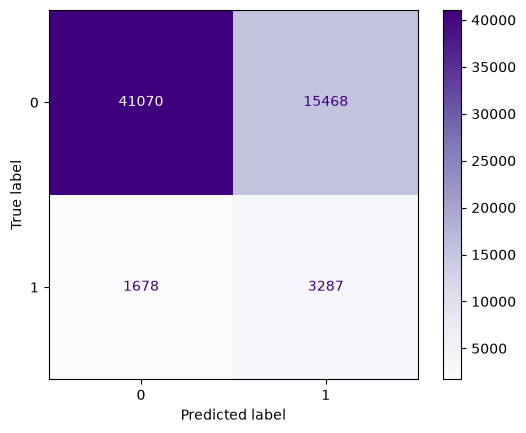

In [33]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, cmap="Purples")

In [32]:
import joblib, os
import shap

joblib.dump(best_lgbm, "../app/lightgbm_model.pkl")

explainer = shap.TreeExplainer(best_lgbm)
joblib.dump(explainer, "../app/shap_explainer.pkl")

['../app/shap_explainer.pkl']